# GTP3 INGENIERA DE CARACTERISTICAS Y SELECCION DE VARIABLES


### Descargo el coso

In [1]:
import gdown
file_id = '1artALqi9at8DqzTp5x8NA7P1qwJLKN24'
gdown.download(id=file_id, output='worldbank_dataset.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1artALqi9at8DqzTp5x8NA7P1qwJLKN24
To: l:\FACULTAD DE MIERDA\TERCERO\LABORTARIO DE DATOS 2\lab2 - unidad 3\worldbank_dataset.csv
100%|██████████| 2.27M/2.27M [00:00<00:00, 8.01MB/s]


'worldbank_dataset.csv'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

### recordando lo que dijo la profe en clase sobre las variables que dan mucha informacio sobre la variable objetivo

Identifique algunas variables que si las dejamos produciria data leakage debido a que son formulas matematicas directas de la variable objetivo. Si la dejamos el modelo va a parecer perfecto pero es pq basicamente le estamos dando las respuestas.
- **gdp_current_us$**(Entiendo que es el PBI total absoluto): El PBI percapita se calcula dividiendo el PBI total por la poblacion, si le damos el total ya la estariamos dando media respuesta
- **gdp_ppp_current_international_$**(PIB ajustado por paridad de poder adquisitivo): Lo busque y es basicamente lo mismo que queremos predecir (mide la riqueza), poero ajustada a al inflacion y costo de vida, es un sinonimo literal, ARAFUE.
- **gdp_per_capita_growth_annual y gdp_growth_annual**:Son las tasas de crecimiento analues, derivan directamente de nuestra variable objetivo en el tiempo.

In [3]:
df=pd.read_csv('worldbank_dataset.csv')

#lista de variables que se van
columnas_arafue = [
    'gdp_current_us$', 
    'gdp_ppp_current_international_$', 
    'gdp_per_capita_growth_annual', 
    'gdp_growth_annual'
]

# Eliminarlas del DataFrame
df = df.drop(columns=columnas_arafue)

print(f"tamaño del dataset: {df.shape}") #habia 64 columnas originalmente
df.head()

tamaño del dataset: (3429, 60)


,country,year,heritage_score,property_rights,government_integrity,judicial_effectiveness,tax_burden,government_spending,fiscal_health,business_freedom,...,primary_energy_consumption_constant_2017_ppp_$,real_interest_rate,renewable_energy_consumption_of_total_final_energy_use,school_enrollment_primary_gross,school_enrollment_secondary_gross,school_enrollment_tertiary_gross,services_value_added_of_gdp,trade_of_gdp,unemployment_total_of_total_labor_force,unemployment_youth_ages_15-24
0,Albania,2022,66.6,55.5,35.6,49.8,89.1,72.1,70.6,70.7,...,2.06,-3.053767,NaN,96.371231,97.322472,62.647919,46.209426,84.698057,10.137,24.735
1,Albania,2021,65.2,46.1,40.6,22.8,89.0,74.6,86.6,66.1,...,2.27,2.491460,41.9,97.107498,97.665031,59.969872,45.243846,75.590322,11.474,27.244
2,Albania,2020,66.9,57.1,38.8,33.0,85.9,74.6,86.3,65.7,...,2.34,6.077295,44.4,100.020973,95.929451,61.585300,45.721359,59.520712,11.690,28.117
3,Albania,2019,66.5,54.8,40.4,30.6,86.3,73.9,80.6,69.3,...,2.45,5.222938,40.1,102.589539,99.015152,61.408508,45.453411,75.382129,11.466,26.942
4,Albania,2018,64.5,54.1,39.9,25.4,85.1,72.7,67.5,69.1,...,2.53,4.415049,37.8,104.568024,98.822388,56.080299,44.397028,75.694078,12.304,28.109


vemos un poco los datos

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3429 entries, 0 to 3428
Data columns (total 60 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   country                                                 3429 non-null   object 
 1   year                                                    3429 non-null   int64  
 2   heritage_score                                          3231 non-null   float64
 3   property_rights                                         3250 non-null   float64
 4   government_integrity                                    3262 non-null   float64
 5   judicial_effectiveness                                  860 non-null    float64
 6   tax_burden                                              3241 non-null   float64
 7   government_spending                                     3251 non-null   float64
 8   fiscal_health                         

Verificamos que no haya columnas con errores de tipeo, es decir que tengan algun texto pero deberian ser numericas.  A SIMPLE VISTA PARECERIA QUE NO IGUAL PERO SON MUCHAS COLUMNAS

In [5]:
#segun el dataset, las que deberian ser texto son 'iso_code','country','coountryiso3'
columnas_texto=['iso_code','country','countryiso3']
#hacemos un intento de filtro para ver cuales pueden tener errores de tipeo
#por ejemplo se le coloco alguna 'N/A' o "" en las numericas
columnas_sospechochas=df.select_dtypes(include=['object']).columns
columnas_con_errores= [col for col in columnas_sospechochas if col not in columnas_texto]
print(f"Columnas numericas con errores: {len(columnas_con_errores)}")



Columnas numericas con errores: 0


EL  DATASET MAS LIMPIO DE LA HISTORIA

# EJERCICIO 1: Análisis Exploratorio, Tratamiento de Faltantes y Preparación de Variables 

## 1.1 Analisis exploratorio inicial (siguiendo tal cual la consigna,no agregamos nada mas)

### Faltantes

PROPORCIÓN DE VALORES FALTANTES
TOTAL DE VARIABLES CON NULOS: 54


,Porcentaje NaN (%)
adult_literacy_rate_of_people_ages_15_and_above,80.14
fiscal_health,75.04
judicial_effectiveness,74.92
central_government_debt_of_gdp,65.88
gini_index,54.10
poverty_headcount_ratio_at_$1.90_day_of_population,54.10
poverty_headcount_ratio_at_$5.50_day_of_population,54.10
high-technology_exports_of_manufactured_exports,45.55
real_interest_rate,34.35
school_enrollment_tertiary_gross,28.99


C:\Users\lioju\AppData\Local\Temp\ipykernel_12712\2974863833.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=faltantes.values[:15], y=faltantes.index[:15], palette="magma")


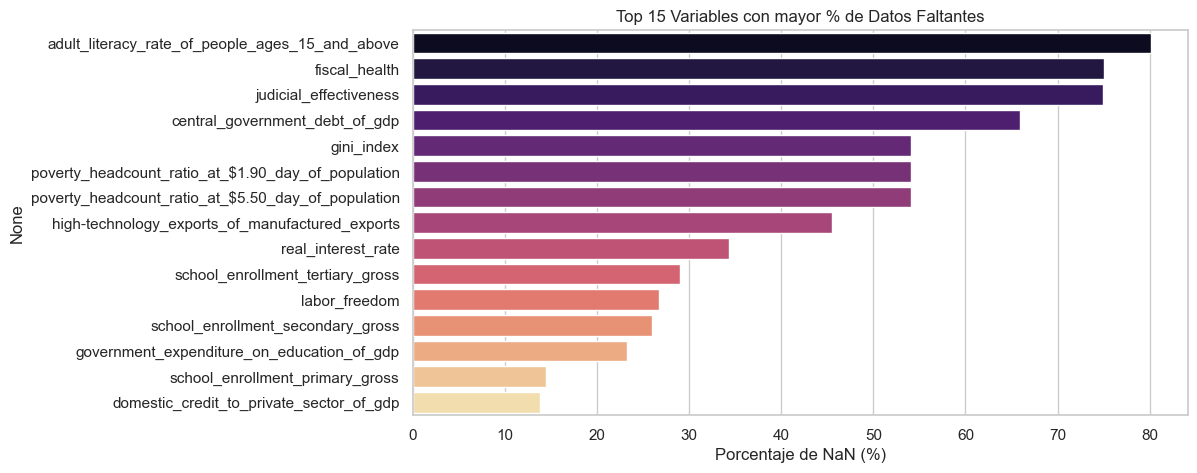

In [6]:
print("PROPORCIÓN DE VALORES FALTANTES")
faltantes = (df.isnull().sum() / len(df)) * 100
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
total_faltantes=len(faltantes)
print(F"TOTAL DE VARIABLES CON NULOS: {total_faltantes}")
display(pd.DataFrame({'Porcentaje NaN (%)': faltantes.round(2)}))

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.barplot(x=faltantes.values[:15], y=faltantes.index[:15], palette="magma")
plt.title("Top 15 Variables con mayor % de Datos Faltantes")
plt.xlabel("Porcentaje de NaN (%)")
plt.show()


**CONCLUSION**:
Vemos que 'adult_literacy_rate', 'fiscal_health' y 'judicial_effectiveness' tienen 75% o mas de datos faltantes, imputar estas no tendria sentido porque estariamos "inventando" datos, las **descartamos**


Elijo algunas variables numericas que me parezcan "principales", intento justificar el por que:

- **life_expectancy_at_birth_total_years**: (Expectativa de vida): Un excelente indicador de la calidad general del sistema de salud, nutricion y saneamiento de un pais.
- **infant_mortality_rate_per_1_000_live_births**:(Mortalidad infantil): Un indicador sensible a la falta de recursos y pobreza extrema. entiendo que de aca se espera que tenga una correlacion fuertemente negativa con la riqueza del pais.
- **agriculture_value_added_of_gdp**: (Valor agregado de agricultura %): En economias en desarrollo, este sector suele representar una porcion muy alta del PIB. A mayor riqueza, este porcentaje tiende a disminuir.
- **services_value_added_of_gdp**: (Valor agregado de servicios %): Las economias mas desarrolladas se caracterizan por tener un sector de servicios dominante.
- **school_enrollment_tertiary_gross** (Matriculacion terciaria/universitaria): El nivel educativo superior es el motorcito de todo,es necesaria en un pais top (le pregunte al amigo). En nuestro pais esto debe estar re gaga
- **access_to_electricity_of_population**: (Acceso a la electricidad %): Con esto capaz filtramos a pobalciones pobres.
- **inflation_consumer_prices_annual**: (Inflación anual %): Mide la estabilidad de precios de la economia. Altos niveles de inflacion suelen asociarse a menor desarrollo o estancamiento.
- **trade_of_gdp**: (Comercio como % del PIB): Representa la suma de exportaciones e importaciones. Mide que tan abierta esta la economia de un pais hacia el mercado global. NO LO DIGO YO, LO DICE LA HISTORIA PERO ME GUARDO MIS COMENTARIOS

In [7]:
#definimos el Target y 8 variables principales A MI PARECER, SOBRE TODO EN RELAACION AL TARGET
target = 'gdp_per_capita_current_us$'

principales_vars = [
    target,
    'life_expectancy_at_birth_total_years', 
    'infant_mortality_rate_per_1_000_live_births',
    'agriculture_value_added_of_gdp',
    'services_value_added_of_gdp',
    'school_enrollment_tertiary_gross',
    'access_to_electricity_of_population',
    'inflation_consumer_prices_annual',
    'trade_of_gdp'
]


reporte = pd.DataFrame(index=principales_vars)

#rango
reporte['Mínimo'] = df[principales_vars].min()
reporte['Máximo'] = df[principales_vars].max()

#log10 del máximo absoluto, pq decia algo del orden
reporte['Orden Magnitud (10^x)'] = np.log10(df[principales_vars].abs().max()).round(1)

#Asimetria
reporte['asimetria'] = df[principales_vars].skew()

print("ANALISIS DE RANGO, MAGNITUD Y FORMA")
display(reporte.round(2))


ANALISIS DE RANGO, MAGNITUD Y FORMA


,Mínimo,Máximo,Orden Magnitud (10^x),asimetria
gdp_per_capita_current_us$,62.14,134965.82,5.1,2.31
life_expectancy_at_birth_total_years,14.66,84.56,1.9,-0.80
infant_mortality_rate_per_1_000_live_births,1.70,234.90,2.4,1.40
agriculture_value_added_of_gdp,0.03,79.04,1.9,1.42
services_value_added_of_gdp,6.45,94.15,2.0,-0.22
school_enrollment_tertiary_gross,0.26,166.67,2.2,0.44
access_to_electricity_of_population,1.30,100.00,2.0,-1.19
inflation_consumer_prices_annual,-16.86,2666.45,3.4,40.84
trade_of_gdp,0.02,437.33,2.6,2.47


- las escalas son disparejas, 'life_expectancy' se mueve en decenas, la inflacion llega a miles y el PIB per capita esta en los cientos de miles(10^5). Por lo tanto **es obligatorio aplicar tecnincas de escalado**

- En cuanto a la asimetria, praticamente ninguna tiene una dist Gaussiana. La inflacion ('inflation_consumer_prices') tiene una asimetria terrible de 40,84.... esto indica que hay valores extremos claros como paises con HIPERINFLACION. Nuestro target tambien tiene asimetria fuerte hacia la derecha con 2.31. Para estabilizar esto debemos aplicar transformaciones como Yeo-Johnson, logaritmo o box-cox


### Graficos

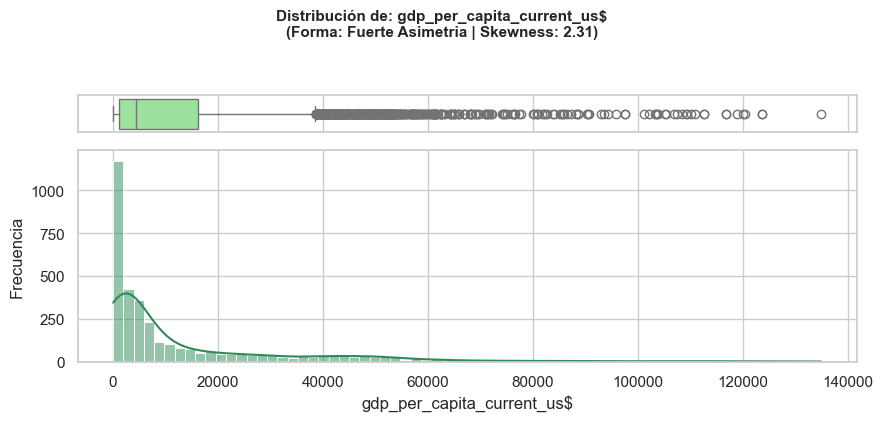

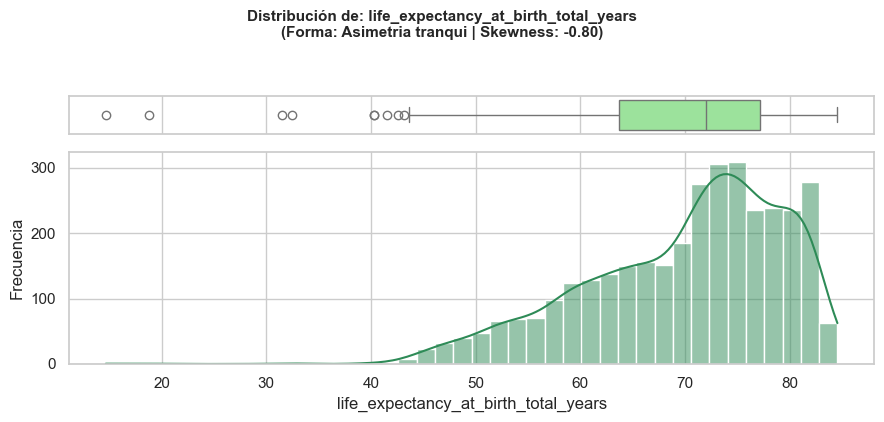

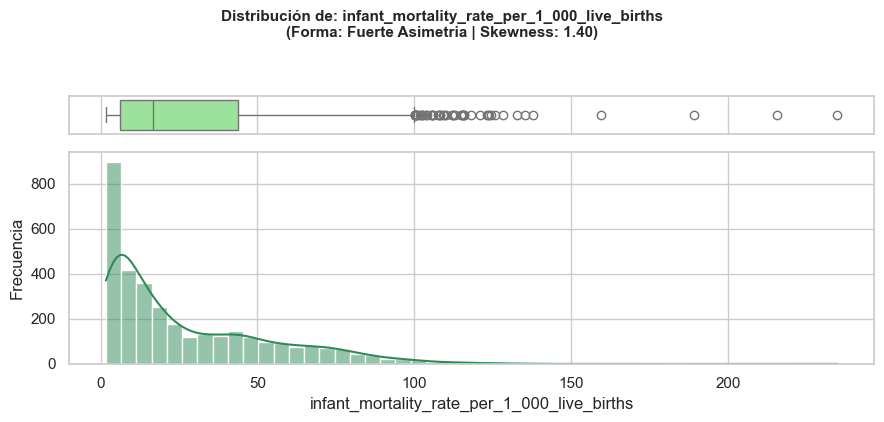

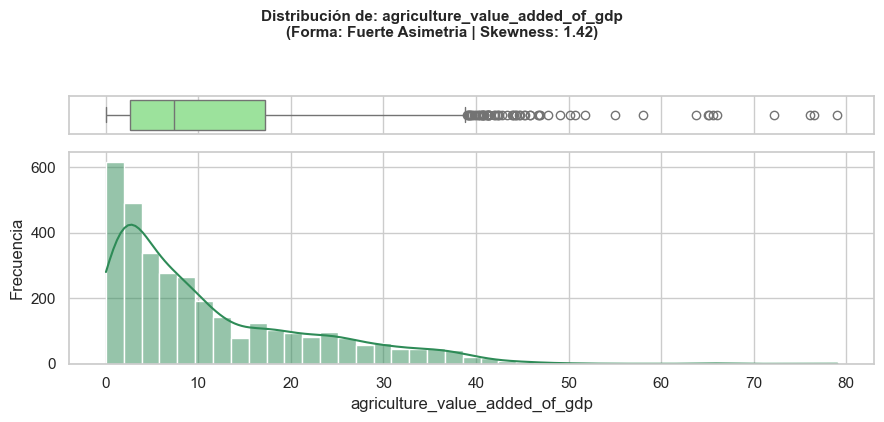

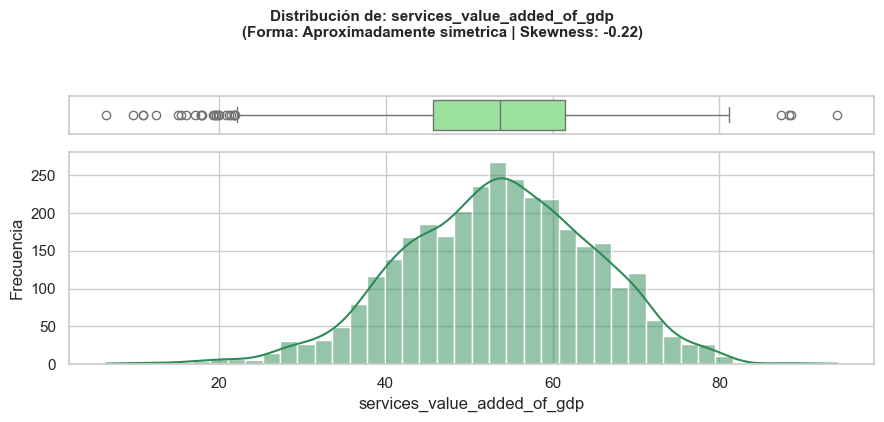

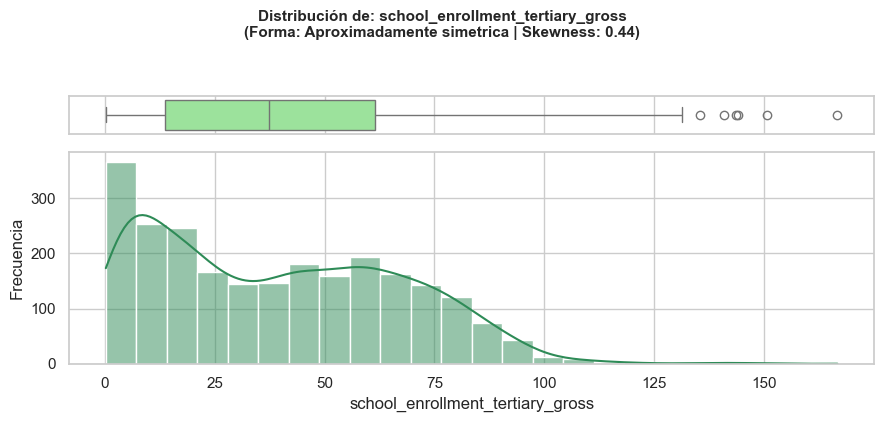

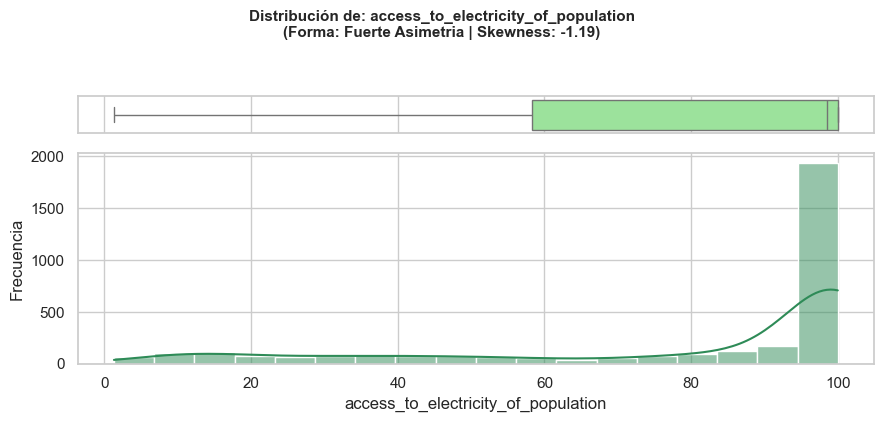

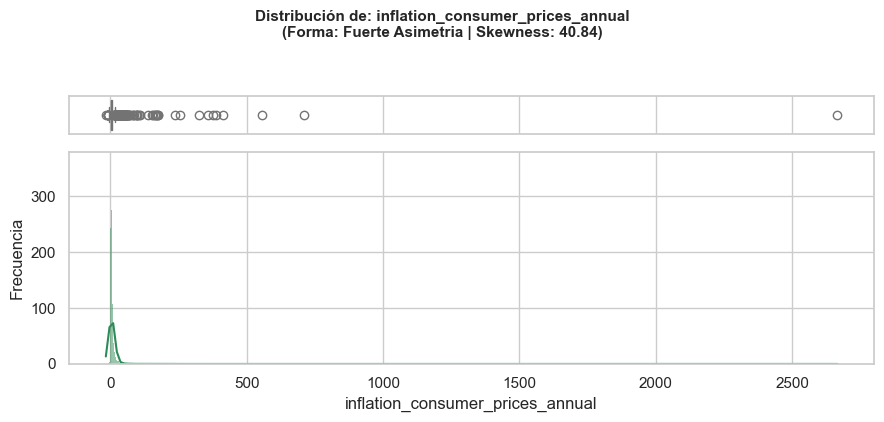

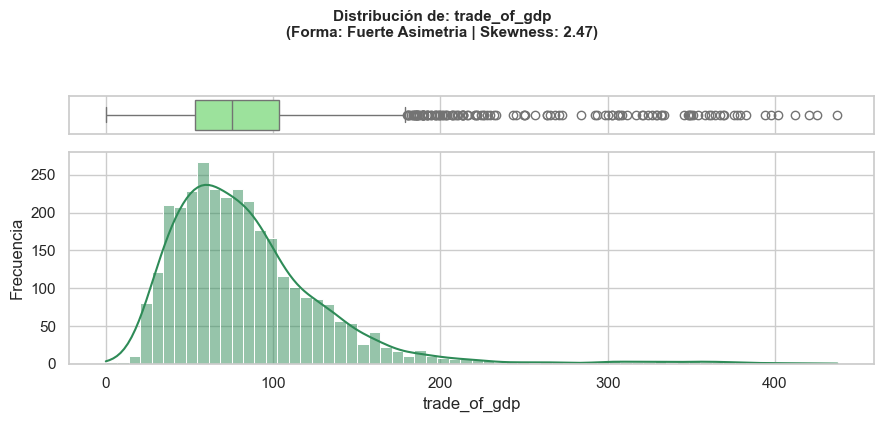

In [8]:
#histograma y Boxplot solo para nuestras variables principales
for col in principales_vars:
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2, 
        sharex=True, 
        gridspec_kw={"height_ratios": (.15, .85)}, 
        figsize=(9, 4)
    )

    sns.boxplot(x=df[col], ax=ax_box, color="lightgreen")
    sns.histplot(data=df, x=col, ax=ax_hist, kde=True, color="seagreen")
    ax_box.set(xlabel='')
    ax_hist.set_ylabel("Frecuencia")
    #ponemos la asimetria tmb
    skew_val = df[col].skew()
    
    if abs(skew_val) > 1:
        forma = "Fuerte Asimetria"
    elif abs(skew_val) > 0.5:
        forma = "Asimetria tranqui"
    else:
        forma = "Aproximadamente simetrica"
        
    plt.suptitle(f'Distribución de: {col}\n(Forma: {forma} | Skewness: {skew_val:.2f})', 
                 y=1.05, fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


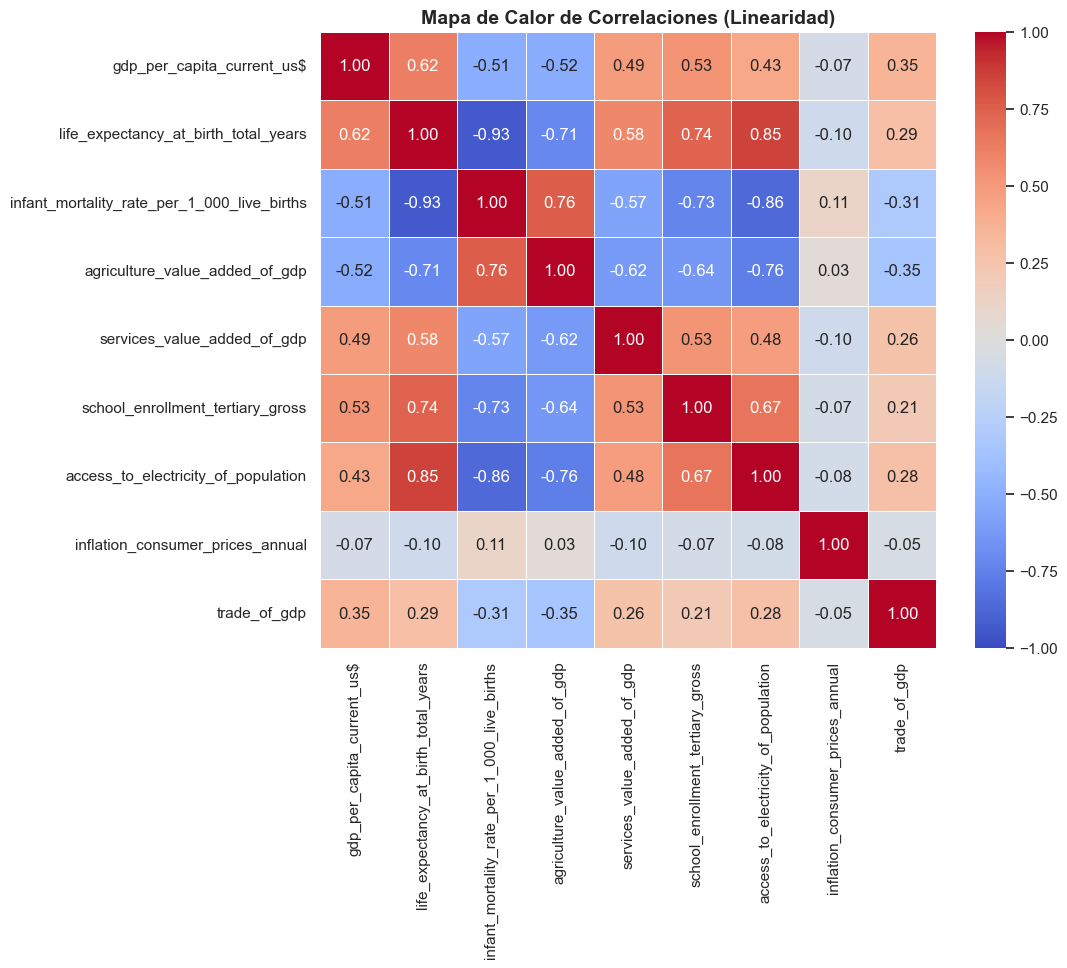

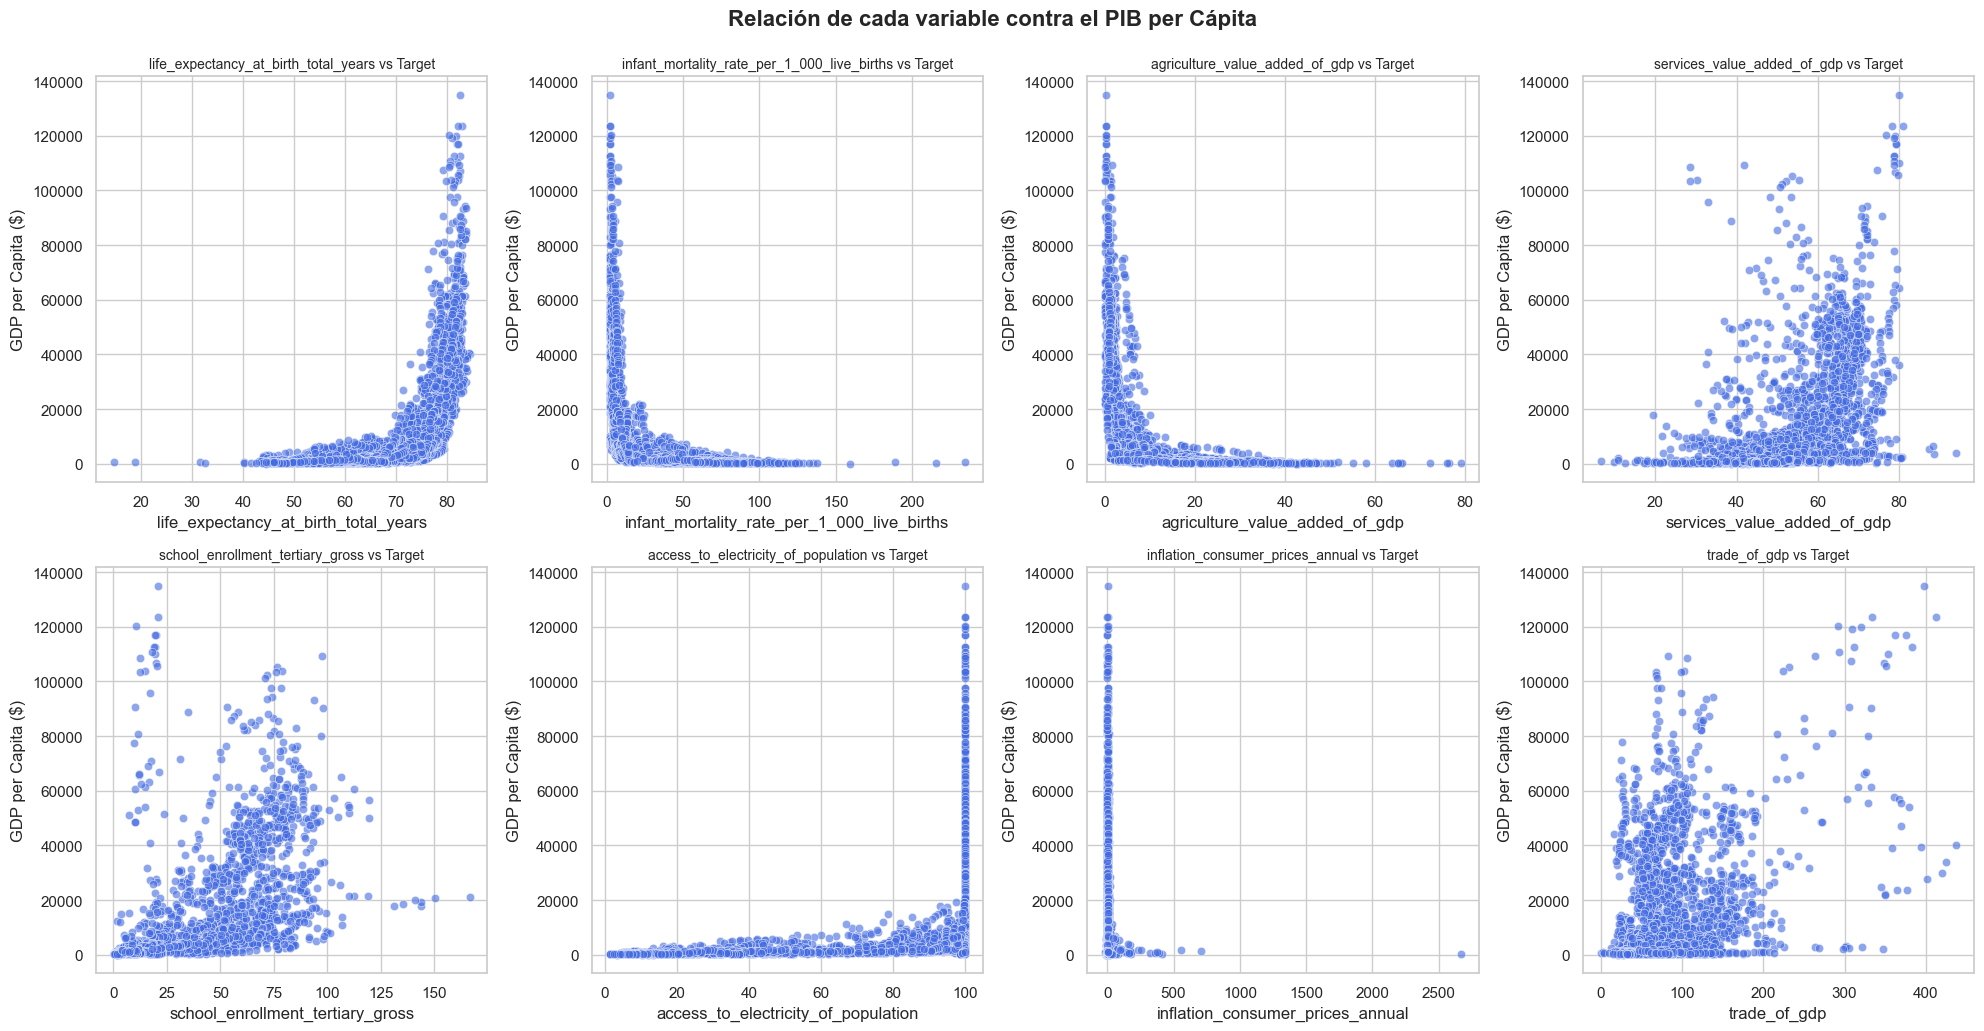

In [9]:
#Heatmap
plt.figure(figsize=(10, 8))
matriz_correlacion = df[principales_vars].corr()

sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", 
            cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("Mapa de Calor de Correlaciones (Linearidad)", fontsize=14, fontweight='bold')
plt.show()

#Scatter plots contra el Target
#quitamos el target de la lista para iterar solo sobre las predictoras
variables_predictoras = [var for var in principales_vars if var != target]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(variables_predictoras):
    sns.scatterplot(data=df, x=col, y=target, ax=axes[i], alpha=0.6, color="royalblue")
    axes[i].set_title(f'{col} vs Target', fontsize=10)
    axes[i].set_ylabel("GDP per Capita ($)")
    
plt.tight_layout()
plt.suptitle("Relación de cada variable contra el PIB per Cápita", y=1.03, fontsize=16, fontweight='bold')
plt.show()


- En el heatmap vemos que el PIB tiene correlaciones positivas fuertes con la **expectativa de vida** como sospechabamos mas arriba y con la **educacion terciaria**, y tiene correlaciones negativas con la **mortalidad infantil** y la **dependencia agricola**.

- En los graficos de dispersion vemos que no tenemos relaciones lineales rectas, como que se forman muros directamente, todos los datos se agrupan. Esto indica que una regresion lineal simple nos daria muy mal para predecir el target en este estado.

## 1.2 Tratamiento de valores faltantes

Vimos antes que podiamos eliminar algunas variables.... como la consigna dice en la observacion que **no deben entenderse 
como una modificación definitiva del dataset**, por las dudas no elimino nada y trabajo en un .copy

In [10]:
df_ej1 = df.copy()
#miro las columnas con mas de 40% de datos nulos, son muchisimos nulos
umbral_faltantes = 40.0
cols_num = df_ej1.select_dtypes(include=['float64', 'int64']).columns

#calculamos nuevamente el porcentaje de nulo
porcentaje_nulos = (df_ej1[cols_num].isnull().sum() / len(df_ej1)) * 100
columnas_a_eliminar = porcentaje_nulos[porcentaje_nulos > umbral_faltantes].index.tolist() #para saber el nombre de las columnas

print("columnas encontradas con mas de 40% de nulos: ")
for col in columnas_a_eliminar:
    print(f" - {col} ({porcentaje_nulos[col]:.1f}% NaN)")


columnas encontradas con mas de 40% de nulos: 
 - judicial_effectiveness (74.9% NaN)
 - fiscal_health (75.0% NaN)
 - adult_literacy_rate_of_people_ages_15_and_above (80.1% NaN)
 - central_government_debt_of_gdp (65.9% NaN)
 - gini_index (54.1% NaN)
 - high-technology_exports_of_manufactured_exports (45.6% NaN)
 - poverty_headcount_ratio_at_$1.90_day_of_population (54.1% NaN)
 - poverty_headcount_ratio_at_$5.50_day_of_population (54.1% NaN)


Estas variables tienen tantos nulos por algo en especifico? es decir, la ausencia de datos es informacion?

POR EJEMPLO EN **fiscal_healt**, ME PARECE UNA VARIABLE QUE SE RELACIONA MUCHO EN LO TEORICO A NUESTRO TARGET... TENGO COMO HIPOTESIS QUE QUIZAS FALTA EL DATO EN PAISES  POBRES Y QUE LA AUSENCIA DEL MISMO ES UNA SEÑAL DE POBREZA (O CORRUPCION)

In [11]:
#veamos si la falta de datos en estas columnas es indicador de pobreza
#las comparo con el target (la variable esta mas arriba)

for col in columnas_a_eliminar:
    #me fijo si el dato es nulo
    es_nulo = df_ej1[col].isnull()
    #calculamos la mediana del PIB para los que reportan el dato y los que no
    mediana_con_datos = df_ej1[~es_nulo][target].median()
    mediana_sin_datos = df_ej1[es_nulo][target].median()
    diferencia_porcentual = ((mediana_con_datos / mediana_sin_datos) - 1) * 100

    print(f"Variable: [{col}]")
    print(f"  PBI Mediano CON datos: ${mediana_con_datos:,.2f}")
    print(f"  PBI Mediano SIN datos: ${mediana_sin_datos:,.2f}")

    # Señalizamos si la diferencia es grande
    if diferencia_porcentual > 50:
        print(f"Los países CON datos son {diferencia_porcentual:.0f}% más ricos.")
    elif diferencia_porcentual < -30:
        print(f"Los países SIN datos son {abs(diferencia_porcentual):.0f}% más ricos.")
    else:
        print(f"Neutro: No hay una diferencia grande por la ausencia del dato.")
    print("-" * 70) 

Variable: [judicial_effectiveness]
  PBI Mediano CON datos: $6,197.55
  PBI Mediano SIN datos: $3,973.51
Los países CON datos son 56% más ricos.
----------------------------------------------------------------------
Variable: [fiscal_health]
  PBI Mediano CON datos: $6,205.34
  PBI Mediano SIN datos: $3,969.20
Los países CON datos son 56% más ricos.
----------------------------------------------------------------------
Variable: [adult_literacy_rate_of_people_ages_15_and_above]
  PBI Mediano CON datos: $3,880.69
  PBI Mediano SIN datos: $4,618.00
Neutro: No hay una diferencia grande por la ausencia del dato.
----------------------------------------------------------------------
Variable: [central_government_debt_of_gdp]
  PBI Mediano CON datos: $7,809.24
  PBI Mediano SIN datos: $3,077.20
Los países CON datos son 154% más ricos.
----------------------------------------------------------------------
Variable: [gini_index]
  PBI Mediano CON datos: $8,185.11
  PBI Mediano SIN datos: $2,22

Podemos ver clamente que en el  indice **gini, pobreza y exportaciones tecnoclogicas** los paises que tienen capacidad para reportar estos datos tienen entre un 230% y 260% mas de PBI per capita (son mas ricos), por su parte, los paises que registran el dato de su **deuda** son 154% mas ricos y los que tienen el dato de la **efectividad judicial y salud fiscal** son 56% mas ricos.

- Entiendo que la ausencia de datos no es aleatoria (MNAR), **LA AUSENCIA APORTA INFORMACION**. Imputar mas del 50% de los datos creo que va a introducir mucho ruido, por lo que , segun la consulta que hicimos y la respuesta obtenida, entiendo que debemos eliminar las variables justamente por la cantidad de datos faltantes.

- En un analisis de datos real, ya creariamos una variable auxiliar para **gini** por ejemplo ya que su falta de datos es justamente informacion muy valiosa como vimos

In [12]:
df_ej1 = df_ej1.drop(columns=columnas_a_eliminar, errors='ignore')
print(f"Tamaño actual del dataset: {df_ej1.shape}")



Tamaño actual del dataset: (3429, 52)


 - real_interest_rate: 34.4% NaN
 - school_enrollment_tertiary_gross: 29.0% NaN
 - labor_freedom: 26.7% NaN
 - school_enrollment_secondary_gross: 26.0% NaN
 - government_expenditure_on_education_of_gdp: 23.2% NaN
 - school_enrollment_primary_gross: 14.4% NaN
 - domestic_credit_to_private_sector_of_gdp: 13.9% NaN
 - energy_use_kg_of_oil_equivalent_per_capita: 13.9% NaN
 - freedom_to_trade_internationally: 10.8% NaN
 - gross_capital_formation_of_gdp: 9.7% NaN
 - annual_freshwater_withdrawals_of_internal_resources: 9.7% NaN
 - imports_of_goods_and_services_of_gdp: 6.9% NaN
 - trade_of_gdp: 6.9% NaN
 - exports_of_goods_and_services_of_gdp: 6.9% NaN
 - primary_energy_consumption_constant_2017_ppp_$: 6.2% NaN


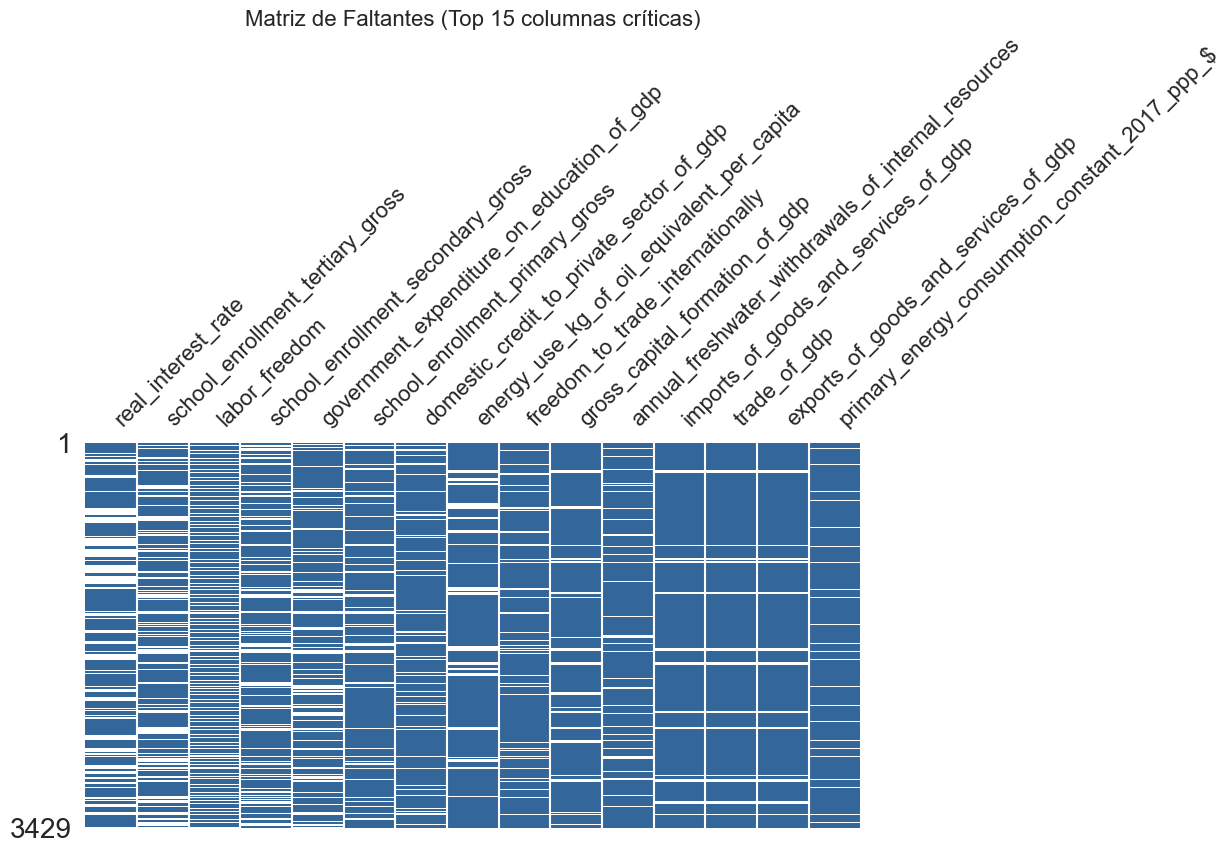

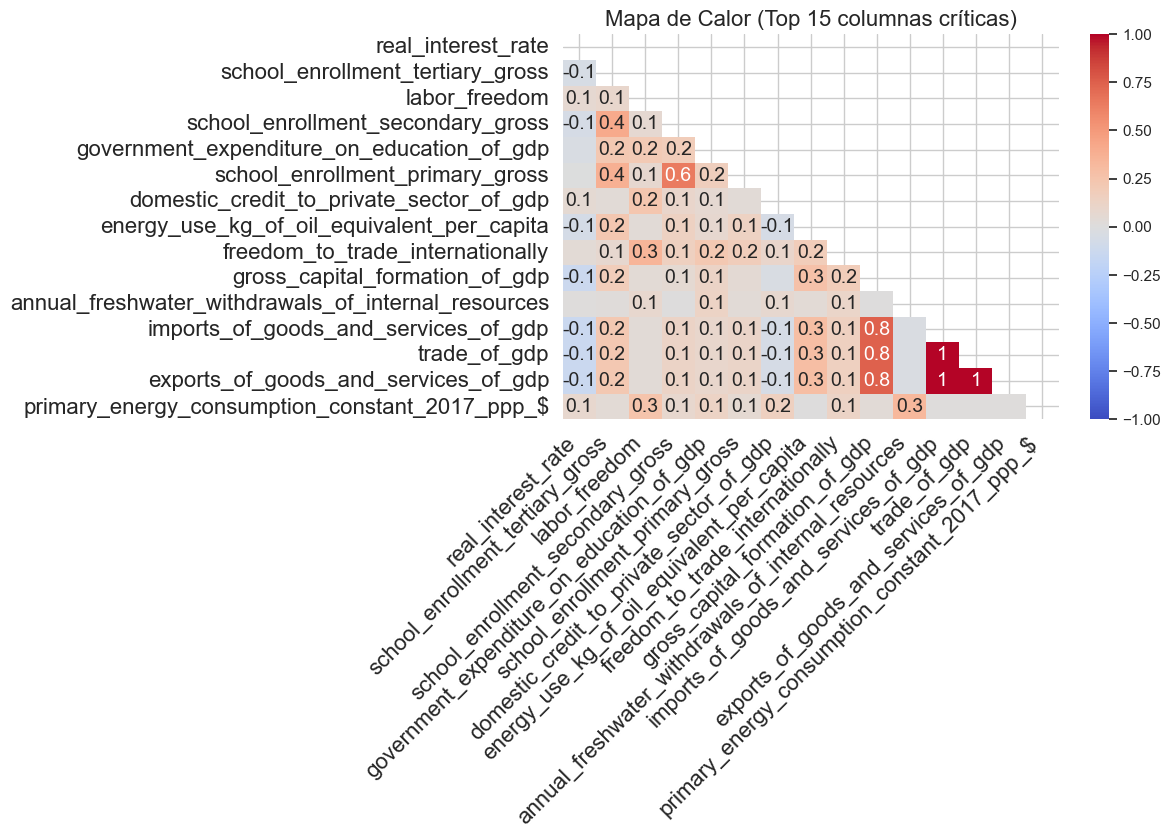

In [13]:
import missingno as msno
cols_num_restantes = df_ej1.select_dtypes(include=['float64', 'int64']).columns

nulos_restantes = df_ej1[cols_num_restantes].isnull().sum()
nulos_restantes = nulos_restantes[nulos_restantes > 0].sort_values(ascending=False)
top_15_columnas = nulos_restantes.head(15).index.tolist()
#nos quedamos con el top 15
porcentajes_top15 = (nulos_restantes.head(15) / len(df_ej1)) * 100

for col, pct in porcentajes_top15.items():
    print(f" - {col}: {pct:.1f}% NaN")

#matriz de nulos
msno.matrix(df_ej1[top_15_columnas], figsize=(10, 5), sparkline=False, color=(0.2, 0.4, 0.6))
plt.title("Matriz de Faltantes (Top 15 columnas críticas)", fontsize=16)
plt.show()

#heatmap de nulos
msno.heatmap(df_ej1[top_15_columnas], figsize=(8, 5), cmap="coolwarm")
plt.title("Mapa de Calor (Top 15 columnas críticas)", fontsize=16)
plt.show()

- Bueno los graficos son horribles... pero bueno observamos que la variable **trade_of_gdp (comercio total)** tiene una correlacion perfecta con **imports_of_goods_and_services_of_gdp (Importaciones)  y exports_of_goods_and_services_of_gdp (Exportaciones)**. Esto se debe a que el comercio total es la suma de las otras dos...
- Luego las variables **school_enrollment_primary_gross y school_enrollment_secondary_gross** tambien tienen relacion, basicamente si un pais es tan enquilombado que no reporta la matricula de escuela primaria, hay un 60% de chances que no reporte el de la secundaria

- Como conclusion  vemos que tenemos variables en las que el patron de ausencia NO es aleatorio (MNAR). Como estos datos faltan por cuestiones internas de los paises (entiendo que los mas enquilombados), no podemos imputar por la media gloabl, usamos un KNN imputer para rellenar con los vecinos.

- APLICAMOS KNN A TODAS LAS VARIABLES RESTANTES CON NULOS: Me parece lo mas correcto, los datos en las 7 variable que detectamos que son MNAR faltan por razones economcias (o eso entiendo yo, es decir son desorganizadas o no muestran sus datos), con KNN buscamos sus vecinos y rellenamos, ya que buscara paises con recursos similares.
-  PAra el resto , si dentro de las de poco porcentaje hay patrones MNAR , es valido usar KNN. Pero si faltan por que se olvidaron de anotarlo por ejemplo, el KNN imputer sigue siendo mas robusto. Lo elegimos por simplicidad.

In [14]:
from sklearn.impute import KNNImputer
#aislamos las de texto para dsp volver a agregarlas
cols_texto = df_ej1.select_dtypes(include=['object']).columns

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df_num_imputado = pd.DataFrame(
    knn_imputer.fit_transform(df_ej1[cols_num_restantes]), 
    columns=cols_num_restantes, 
    index=df_ej1.index #mantenemos el orden
)

df_ej1_imputado = pd.concat([df_ej1[cols_texto], df_num_imputado], axis=1) #axis=1 es para que pegue las columnas

#juntamos las numericas con las 3 de texto y creamos el df imputado, la consigna pedia no tocar nada del original
#esta variable es la mas limpia hasta el momento.

print(f"Total de valores nulos en el dataset: {df_ej1_imputado.isnull().sum().sum()}")


Total de valores nulos en el dataset: 0


## 1.3 Analisis de distribuciones y aplicacion de transformaciones

Usamos el dataset imputado

### ASimetria

In [15]:
cols_num_finales = df_ej1_imputado.select_dtypes(include=['float64', 'int64']).columns

#asimetria
asimetria = df_ej1_imputado[cols_num_finales].skew()

#filtramos la que sean mayor a 1 y menor a -1
variables_sesgadas = asimetria[abs(asimetria) > 1].sort_values(ascending=False)

print(f"Hay {len(variables_sesgadas)} variables numercias que tienen una asimetria grande")

print("\nTop 10 con mas asimetrias: ")
print(variables_sesgadas.head(10))


Hay 21 variables numercias que tienen una asimetria grande

Top 10 con mas asimetrias: 
inflation_consumer_prices_annual                       39.902536
annual_freshwater_withdrawals_of_internal_resources    10.220994
personal_remittances_received_current_us$               6.968708
foreign_direct_investment_net_inflows_current_us$       5.880289
energy_use_kg_of_oil_equivalent_per_capita              2.938513
exports_of_goods_and_services_of_gdp                    2.567972
trade_of_gdp                                            2.464945
gdp_per_capita_current_us$                              2.306740
imports_of_goods_and_services_of_gdp                    1.969378
primary_energy_consumption_constant_2017_ppp_$          1.864449
dtype: float64


Bueno podemos ver que la inflacion es un desastre, tiene 40 de asimetria.
- Notemos tambien que el target es bastante asimetrico, esto entiendo que es normal por que hay pocos paises muy ricos (lo que genera la cola larga hacia la derecha) y muchos paises de ingresos medios/bajos.


### Transformaciones

tenemos en cuenta el dominio de las 21 variables encontradas para aplicar las transformaciones correctas.

In [16]:
from sklearn.preprocessing import PowerTransformer
# hacemos otra copia para despues almacenar las transformadas
df_ej1_transformado = df_ej1_imputado.copy()

#transformadores
pt_boxcox = PowerTransformer(method='box-cox')
pt_yeo = PowerTransformer(method='yeo-johnson')
contadores = {'boxcox': 0, 'log1p': 0, 'yeo-johnson': 0}

columnas_a_transformar = variables_sesgadas.index
for col in columnas_a_transformar:
    #primero nos fijamos el valor minimo
    min_val = df_ej1_imputado[col].min()
    
    if min_val < 0:
        # Si tiene negativos, Yeo-Johnson
        df_ej1_transformado[col] = pt_yeo.fit_transform(df_ej1_imputado[[col]])
        contadores['yeo-johnson'] += 1
        
    elif min_val == 0:
        #si tiene ceros, Box-Cox tira error. usamos log(x+1)
        df_ej1_transformado[col] = np.log1p(df_ej1_imputado[col])
        contadores['log1p'] += 1
        
    else:
        #si son numeros positivos (>0), Box-Cox
        df_ej1_transformado[col] = pt_boxcox.fit_transform(df_ej1_imputado[[col]])
        contadores['boxcox'] += 1

print(f"Box-Cox (Dominio positivo > 0): {contadores['boxcox']} variables")
print(f"Log1p (Dominio que incluye ceros == 0): {contadores['log1p']} variables")
print(f"Yeo-Johnson (Dominio que incluye negativos < 0): {contadores['yeo-johnson']} variables")


Box-Cox (Dominio positivo > 0): 16 variables
Log1p (Dominio que incluye ceros == 0): 3 variables
Yeo-Johnson (Dominio que incluye negativos < 0): 2 variables


Probe usar las 3 de onda nomas, entiendo que tal vez usar solo YEO-JOHNSON era mas simple en logica pero es re contra costos computacionalmente. REquiere lo del proceso iterativo de maxima verosimilituyd que consume mas CPU que las otras dos transformaciones

### Ejemplo de visualizacion

VISUALIZAMOS EL ANTES Y DESPUES


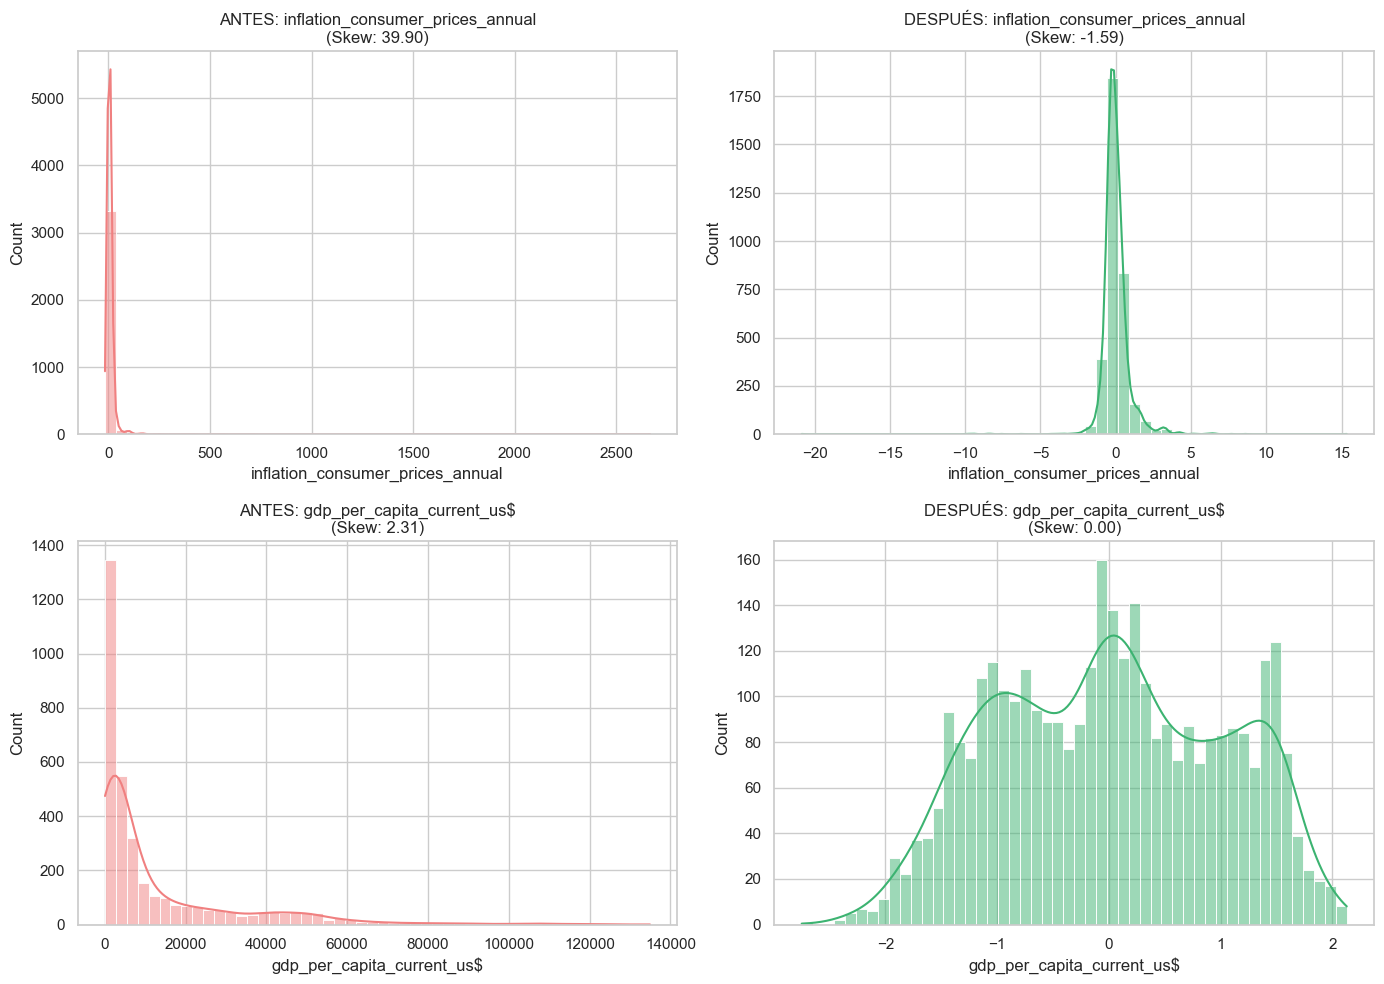

In [17]:
print("VISUALIZAMOS EL ANTES Y DESPUES")
#elegimos dos variables
variables_demo = ['inflation_consumer_prices_annual', 'gdp_per_capita_current_us$']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(variables_demo):
    #grafico del antes (Datos originales con asimetria)
    sns.histplot(df_ej1_imputado[col], kde=True, ax=axes[i, 0], color='lightcoral', bins=50)
    axes[i, 0].set_title(f'ANTES: {col}\n(Skew: {df_ej1_imputado[col].skew():.2f})', fontsize=12)
    
    #grafico del DESPUES (Datos transformados como campana)
    sns.histplot(df_ej1_transformado[col], kde=True, ax=axes[i, 1], color='mediumseagreen', bins=50)
    axes[i, 1].set_title(f'DESPUÉS: {col}\n(Skew: {df_ej1_transformado[col].skew():.2f})', fontsize=12)

plt.tight_layout()
plt.show()


Vemos que variables estrictamente positivas como el target alcanzaron una simetria perfecta con box-cox. Por otro lado, la variable de la inflacion que era sabido que tenia valores negativos (deflacion) se transformo mediante yeo-johnson y paso de tener una simetria de 39.9 a una de -1.5, permitiendo que la podamos incluir en algun modelo lineal.

## 1.4 Estandarizacion

Es necesario cuando en el dataset tenemos variables medidas en unidades o magnitudes diferentes. Por ejemplo en muestro caso el PBI se mide en millones de dolares y el crecimineto poblacional en porcentajes chiquitos. Si no nivelamos esto de alguna forma los modelos tomaran al PBI como millones de veces mas importantes que el crecimiento poblacional solo por tener nros mas grandes.

- Modelos donde es "**imprescindibles**: Calculo de distancias como KNN o SVM pq las distancias se distorsionan si las escalas no son iguales. Algoritmos que usan SGD como RIDGE ya que convergen son mas rapido y sin sesgo si todo tiene la misma escala.
- Modelos donde es "**indiferente**': Basados en arboles de decision, ya que cortan los datos usando reglas logicas, no miden nada, no importa la magnitud.

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#usamos el df transformado, reutilizamos las variables del 1.3
datos_escalados = scaler.fit_transform(df_ej1_transformado[cols_num_finales])

#hacemos una tablita
df_num_estandarizado = pd.DataFrame(
    datos_escalados, 
    columns=cols_num_finales, 
    index=df_ej1_transformado.index
)

#pegamos las columnas de texto que teniamos en 'cols_texto'
df_ej1_final = pd.concat([df_ej1_transformado[cols_texto], df_num_estandarizado], axis=1)

#miniresumen para ver si quedo todo ok
columnas_de_prueba = cols_num_finales[:5]
for col in columnas_de_prueba:
    media = df_ej1_final[col].mean()
    desvio = df_ej1_final[col].std()
    print(f"Variable: {col}")
    print(f" - Media: {media:.4f}")
    print(f" - Desvío: {desvio:.4f}")
    print("-" * 50)


Variable: year
 - Media: 0.0000
 - Desvío: 1.0001
--------------------------------------------------
Variable: heritage_score
 - Media: 0.0000
 - Desvío: 1.0001
--------------------------------------------------
Variable: property_rights
 - Media: -0.0000
 - Desvío: 1.0001
--------------------------------------------------
Variable: government_integrity
 - Media: 0.0000
 - Desvío: 1.0001
--------------------------------------------------
Variable: tax_burden
 - Media: 0.0000
 - Desvío: 1.0001
--------------------------------------------------


# EJERCICIO 2 : METODOS MANUALES Y AUTOMATICOS DE ING DE CARACTERISTICAS

## 2.1 Seleccion de variables base

En el ejercicio 1.2 notamos que habia variables con nulos que tenian una clara relacion con nuestro target. Ademas en el 1.1 hicimos una pre-seleccion por que se nos ocurrio y algunas de las elegidas no se relacionaban mucho con nuestro target. Por eso, dado el analisis que hicimos en estas dos consignas, vemos cuales se relacionan mas para elegir mejor

usamos el df del ejercicio 1 imputado , ya que voy a elegir algunas de las que eliminamos por tener muchos nulos para crear otras variables

In [19]:
#me fijo las correlaciones mas grandes, usamos el df imputado del ej1
todas_correlaciones = df_ej1_imputado.select_dtypes(include=['float64', 'int64']).corr()[target]
todas_correlaciones = todas_correlaciones.drop(target, errors='ignore') #sacamos elt arget

correlaciones_absolutas = todas_correlaciones.abs().sort_values(ascending=False) #filtramos por el valor absoluto

print("Top 10 variables con mayor correlacion  en el dataset limpio:\n")
for col, corr_val in correlaciones_absolutas.head(10).items():
    valor_real = todas_correlaciones[col]
    print(f" - {col}: {valor_real:.4f}")

Top 10 variables con mayor correlacion  en el dataset limpio:

 - government_integrity: 0.7725
 - legal_system_and_property_rights: 0.7245
 - property_rights: 0.7069
 - energy_use_kg_of_oil_equivalent_per_capita: 0.6584
 - heritage_score: 0.6317
 - life_expectancy_at_birth_total_years: 0.6205
 - efw_score: 0.6066
 - domestic_credit_to_private_sector_of_gdp: 0.6048
 - regulation_of_credit_labor_and_business: 0.5789
 - business_freedom: 0.5747


las 3 primeras, junto con puntiacion de herencia y libertad de negocio , son la misma cosa.... miden el invel de sus instituciones, leyes anticorrupcion y libre mercado del pais. Vamos a tener multicolinealidad, es decir todas estas variables le van a  estar dando la misma info. Elijamos columnas que representan mas diversidad en cuanto a la informacion

### Variables elegidas

- **government_integrity (Integridad del gobierno)**: Es la variable que mas correlacion con el target tiene. Captura el nivel de corrupcion institucional, los paises mas transparentes tienen mas inversion y desarrollo que los corruptos
- **energy_use_kg_of_oil_equivalent_per_capita (Uso de energía per cápita)**: Basicamente mide la industrialziacion del pais, quiere decir que tiene muchas fabricas e infraestructura.
- **agriculture_value_added_of_gdp (Valor agregado de la agricultura)**: Tiene correlacion negativa, marca el grado de subdesarrollo... tengo entendido que los paises pobres dependen mas de este sector.
- **services_value_added_of_gdp (Valor agregado de los servicios)**: es la parte contraria de la agricultura, tiene correlacion positiva por lo que se entiende que son economias de primer mundo que tienen muchos servicios y tecnologia.
- **life_expectancy_at_birth_total_years (Expectativa de vida)**:Mucha correlacion y basiamente da info del sistema de salud, nutricion y seguridad de un pais
- **infant_mortality_rate_per_1_000_live_births (Tasa de mortalidad infantil)**:fuerte correlacion negativa, es el indicador social que mas sensible es a la pobreza de un pais y a la falta de infraestructura como hospitales

Las que rescatamos para aprovechar el patron MNAR que presentaban sus nulos
- **gini_index (Índice de desigualdad de Gini)**: se selecciona debido a que sus gran cantidad de faltantes (54%), indican que los paises que omiten este dato suelen tener PIB percapita inferiores, vamos a crear una columna tipo "bandera" para indicar transparencia en sus economias.
- **poverty_headcount_ratio_at_$1.90_day_of_population (Ratio de pobreza extrema)**: Al igual que el anterior, tiene mas del 50% de datos nulos. La vamoa usar para aprovecharnos de esta falta de datos , ya que se entiende que los paises menos desarrolados omiten dar este dato.

In [20]:
target = 'gdp_per_capita_current_us$'

columnas_elite = [
    'government_integrity',
    'energy_use_kg_of_oil_equivalent_per_capita',
    'life_expectancy_at_birth_total_years',
    'agriculture_value_added_of_gdp',
    'services_value_added_of_gdp',
    'infant_mortality_rate_per_1_000_live_births',
    'gini_index',                                        
    'poverty_headcount_ratio_at_$1.90_day_of_population' 
]

#creamos un nuevo df para el ej2, agregamos elt arget y el nombre del pais
df_ej2 = df[['country', target] + columnas_elite].copy()
print(f"el nuevo df tiene {len(columnas_elite)} caracteristicas principales mas el target")

el nuevo df tiene 8 caracteristicas principales mas el target


## 2.2 creacion manual de variables derivadas

mire las indicaciones de la consigna y busque algo que se llama ratio de mmodernizacion de economia que basicamente es el servicio vs la agricultura. Ambos tenian correlaciones de diferentes signos y similares

In [21]:
#empezamos con las BANDERA DE NULOS
#aca notna() nos da true o false y con astype lo pasamos a 1 y 0
df_ej2['tiene_dato_gini'] = df_ej2['gini_index'].notna().astype(int)
df_ej2['tiene_dato_pobreza'] = df_ej2['poverty_headcount_ratio_at_$1.90_day_of_population'].notna().astype(int)

#SERVICIO VS AGRICULTURA crean una especie de RATIO de modernizacion
#el where es como un SI() en excel... (condicion,valor_verdadero,valor_falso)
df_ej2['ratio_servicios_agri'] = np.where(
    df_ej2['agriculture_value_added_of_gdp'] > 0, 
    df_ej2['services_value_added_of_gdp'] / df_ej2['agriculture_value_added_of_gdp'], 
    np.nan
)

#CORTAMOS LA EXPECTATIVA DE VIDA EN 3 CLASES usando los percentiles 33% y 66&
cuantiles_vida=df_ej2['life_expectancy_at_birth_total_years'].quantile([0.33, 0.66]).values
#usamos pd.cut() como indica la consigna y la teoria para el binning manual
df_ej2['categoria_expectativa_vida'] = pd.cut(
    df_ej2['life_expectancy_at_birth_total_years'],
    bins=[0, cuantiles_vida[0], cuantiles_vida[1], 120], # Rango de 0 a 120 años como loco
    labels=['Mortalidad_Alta', 'Mortalidad_Media', 'Mortalidad_Baja']
)

#listo creamos 4 ya ta
#las miramos
df_ej2[['country', 'tiene_dato_gini', 'tiene_dato_pobreza', 'ratio_servicios_agri', 'categoria_expectativa_vida']].sample(10, random_state=42)

,country,tiene_dato_gini,tiene_dato_pobreza,ratio_servicios_agri,categoria_expectativa_vida
578,Cabo Verde,0,0,7.975363,Mortalidad_Media
1055,Ethiopia,0,0,0.838785,Mortalidad_Alta
564,Cabo Verde,0,0,15.735871,Mortalidad_Baja
2298,Netherlands,1,1,37.601157,Mortalidad_Baja
3243,Uganda,1,1,1.960802,Mortalidad_Alta
2225,Mozambique,1,1,1.924278,Mortalidad_Alta
3396,Zambia,0,0,3.920061,Mortalidad_Alta
298,Belgium,1,1,81.311928,Mortalidad_Baja
443,Botswana,0,0,24.402928,Mortalidad_Alta
976,El Salvador,1,1,10.852725,Mortalidad_Media


che soy yo o las banderas quedan iguales, me fijo su correlacion por las dudas

In [22]:
columnas_numericas_ej2 = df_ej2.select_dtypes(include=['float64', 'int32'])
corr_matrix_ej2 = columnas_numericas_ej2.corr()
corr_banderas = df_ej2['tiene_dato_gini'].corr(df_ej2['tiene_dato_pobreza'])
print(f"La correlacion entre las banderas da: {corr_banderas}")

La correlacion entre las banderas da: 1.0


boeee, una cagada las banderas, le pregunte a la IA y me dice que estos ratios se hacen a traves de encuesta en hogares.... asi que nada saco una de las banderas y quedan las variables que quedan

vamos a dejar el df_j2 imputado y listo para lo siguiente

In [23]:
columnas_a_borrar = [
    'tiene_dato_pobreza', 
    'gini_index', 
    'poverty_headcount_ratio_at_$1.90_day_of_population' #una bandera
]
df_ej2 = df_ej2.drop(columns=columnas_a_borrar)

#imputo los nulos con knn, no recuerdo que variables tenia y que no de las otras que elgimos
#primero saco las de texto
cols_texto_ej2 = ['country', 'categoria_expectativa_vida'] 
cols_num_ej2 = df_ej2.select_dtypes(include=[np.number]).columns.tolist()

imputador_ej2 = KNNImputer(n_neighbors=5)
df_ej2_num_imputado = pd.DataFrame(
    imputador_ej2.fit_transform(df_ej2[cols_num_ej2]), 
    columns=cols_num_ej2, 
    index=df_ej2.index
)

#armamos de nuevo el df
df_ej2_2 = pd.concat([df_ej2[cols_texto_ej2], df_ej2_num_imputado], axis=1)


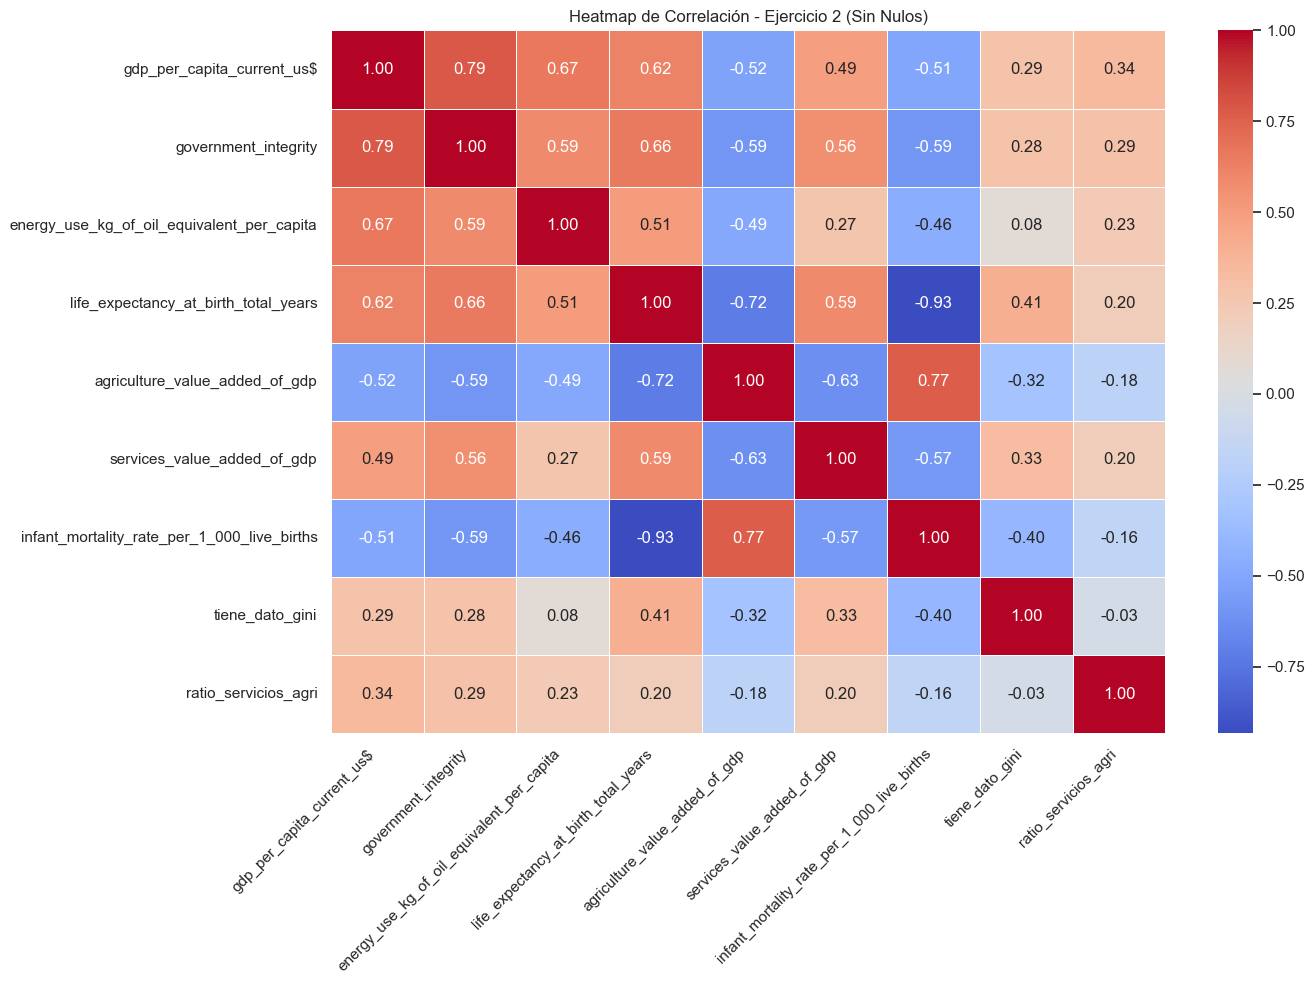

In [24]:
#vemos el heatmap con las variables limpias
columnas_numericas_limpias = df_ej2_2.select_dtypes(include=['float64', 'int32', 'int64'])
corr_matrix_final = columnas_numericas_limpias.corr()
# Configuramos y dibujamos el Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix_final, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap de Correlación - Ejercicio 2 (Sin Nulos)')
plt.xticks(rotation=45, ha='right') # Rotamos las etiquetas para que se lean bien
plt.tight_layout()
plt.show()

## 2.3 Metodos automaticos de generacion  de caracteristicas

me baso en los codigos que muestra la teoria

In [25]:
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer
import itertools

# Seleccionamos las 6 continuas puras para no crear polinomios con nuestras banderas de 1 y 0
cols_base = [
    'government_integrity', 'energy_use_kg_of_oil_equivalent_per_capita', 
    'life_expectancy_at_birth_total_years', 'agriculture_value_added_of_gdp', 
    'services_value_added_of_gdp', 'infant_mortality_rate_per_1_000_live_births'
]

df_auto = df_ej2_2[cols_base].copy()
# Polinomios
# degree=2 significa que hara A^2, B^2, y A*B
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df_auto)
poly_names = poly.get_feature_names_out(cols_base)

df_poly = pd.DataFrame(poly_features, columns=poly_names, index=df_auto.index)
#eliminamos las columnas base porque ya estan incluidas en el df_ej2_2
df_poly = df_poly.drop(columns=cols_base) 


#Sistematicos (Divisiones ciegas)
df_ratios = pd.DataFrame(index=df_auto.index)
#hacemos combinaciones de a 2 (todas contra todas)
for col1, col2 in itertools.combinations(cols_base, 2):
    # Ratio Col1 / Col2
    nombre_ratio_1 = f"ratio_auto_{col1}_div_{col2}"
    df_ratios[nombre_ratio_1] = np.where(df_auto[col2] != 0, df_auto[col1] / df_auto[col2], 0)
    
    # Ratio Col2 / Col1
    nombre_ratio_2 = f"ratio_auto_{col2}_div_{col1}"
    df_ratios[nombre_ratio_2] = np.where(df_auto[col1] != 0, df_auto[col2] / df_auto[col1], 0)


#Binning Automatico (Discretizacion por Cuantiles)
#corta cada variable en 4 grupos iguales
kbins = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
bins_features = kbins.fit_transform(df_auto)
bins_names = [f"bin_auto_{col}" for col in cols_base]

df_bins = pd.DataFrame(bins_features, columns=bins_names, index=df_auto.index)



# Juntamos nuestro df_ej2_final (con las manuales) con toda la basura algorítmica
df_ej2_3 = pd.concat([df_ej2_2, df_poly, df_ratios, df_bins], axis=1)

print(f"Empezamos con {len(df_ej2_2.columns)} columnas.")
print(f"se generaron automaticamente {len(df_poly.columns)} polinomios, {len(df_ratios.columns)} ratios ciegos, y {len(df_bins.columns)} binnings.")
print(f"quedamos con {len(df_ej2_3.columns)} características totales!")


Empezamos con 11 columnas.
se generaron automaticamente 21 polinomios, 30 ratios ciegos, y 6 binnings.
quedamos con 68 características totales!


C:\Users\lioju\Python310\lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.meshgrid() que pedia la consigna agarra dos listas de numeros y las combina para crear una plano XY basicamente, si tenemos 100 paises no te devuelve 1 columna de 100 valores, te devuelve una matriz gigante de 100x100 , seria un caos. No se no lo vi necesario utilizar, no lo entendi mucho que digamos y no me parecia tan util la verdad, romperia la dimensionalidad

## 2.4 Comparacion de enfoques manual vs automatico

vamos a comparar las correlaciones de las manuales contra las automaticas sobre el target

In [29]:
import numpy as np
#vemos las manuales
cols_manuales = ['tiene_dato_gini', 'ratio_servicios_agri']
df_solo_manuales = df_ej2_3[cols_manuales + [target]]
 
# drop(target) elimina la correlacion del PBI consigo mismo
# abs() pasa los valores a absoluto para ver la 'fuerza predictiva' sin importar el signo.
corr_manual = df_solo_manuales.corr()[target].drop(target).abs()
print("correlaciones manuales:")
print(corr_manual.sort_values(ascending=False))

#evaluamos las automaticas
# (polinomios, ratios ciegos y discretización por cuantiles)
cols_automaticas = list(df_poly.columns) + list(df_ratios.columns) + list(df_bins.columns)
df_solo_automaticas = df_ej2_3[cols_automaticas + [target]]
corr_auto = df_solo_automaticas.corr()[target].drop(target).abs()
print("="*10)
print("TOP 5 VARIABLES AUTOMATICAS (de todas las generadas):")
print(corr_auto.sort_values(ascending=False).head(5))

correlaciones manuales:
ratio_servicios_agri    0.337095
tiene_dato_gini         0.286078
Name: gdp_per_capita_current_us$, dtype: float64
TOP 5 VARIABLES AUTOMATICAS (de todas las generadas):
ratio_auto_government_integrity_div_infant_mortality_rate_per_1_000_live_births           0.833581
government_integrity life_expectancy_at_birth_total_years                                 0.820058
government_integrity^2                                                                    0.812167
government_integrity services_value_added_of_gdp                                          0.797207
ratio_auto_services_value_added_of_gdp_div_infant_mortality_rate_per_1_000_live_births    0.789715
Name: gdp_per_capita_current_us$, dtype: float64


Un quilombo de nombres las automaticas...
- la primera es la que creamos en el for nosotros, es la que divide la integridad del gobierno por la mortalidad infantil.
- La segunda es la integridad del gobierno multiplcada por expectativa de vida
- La tercera es la integridad del gobierno al cuadrado.
- la cuarta es la integridad el gobierno por valor de los servicios
- La quinta es valor de servicios dividio por la mortalidad infantil

En conclusion el enfoque automatico logro metricas superiores pero hizo mezclas rarasd, como le explicamos a alguien que para subir el PBI tiene que aumentar la variable "integridad del gobiernoÇ" dividida por la "mortalidad infantil"? , no tiene sentido. 
- Entiendo entonces que las automaticas son mejores para darselos a una red neuronal por ejemplo, pero las manuales son mucho mejor para explicarle el modelo a una persona.

Ahora bien, como "comparacion de utilidad discriminativa" (lo que dice la consigna), supongo que se referia a la correlacion , en donde vimos que el enfoque automatico representa mayor utilidad.
- A pesar de los numeros facheros que tiene el enfoque automatico, me voy a quedar con el enfoque manual, las variables automaticos no tienen mucho sentido, es decir no se pueden interpretar, tipo como recomiendo aumentar la integridad del gobierno al cuadrado? jajajajaja. Las automaticos sirven si es todo un modelo de caja negra  enfocado en minimizar el error.

- Enfoque manual:
    - ventajas
        - Son interpretables
        - permiten capturar mejor la informacion de los datos faltantes mediante banders
        - no generan maldicion de dimensionalidad
    - desventajas
        - Si no sos experto en economia esta complicado darle utilidad
        - requiere mucho analisis previo
        
- Enfoque automatico
    - ventajas
        - es rapido y explora muchas combinaciones
        - maximiza la correlacion
        - ideal para mejorar el rendimiento de modelos
    - desventajas
        - caja negra
        - maldicion de la dimensionalidad


## Guardo el df_ej2_3 por si lo quiero abrir en otra notebook, esta quedo muy cargada ya

In [30]:
df_ej2_3.to_csv('dataset_ej2.csv', index=False)